# Proyecto Final – CallMeMaybe: Identificación de Operadores Ineficaces

**Contexto de negocio**

CallMeMaybe es un servicio de telefonía virtual que distribuye un gran volumen de llamadas entre los operadores de sus clientes.  
La dirección quiere ayudar a los supervisores a detectar **operadores ineficaces** para poder capacitarlos o reasignarlos.

En este proyecto se considera que un operador es ineficaz si:

- Tiene una **alta proporción de llamadas entrantes perdidas**.
- Presenta **tiempos de espera elevados** para las llamadas entrantes.
- Y, cuando debe hacer llamadas salientes, realiza **pocas llamadas outbound** en comparación con sus colegas.

**Objetivos del análisis**

- Explorar los datos de uso del sistema de CallMeMaybe.
- Construir métricas por operador que permitan evaluar su desempeño.
- Identificar a los operadores potencialmente ineficaces.
- Comprobar estadísticamente si los operadores marcados como ineficaces:
  - Tienen **mayor tiempo de espera medio**.
  - Tienen **mayor porcentaje de llamadas perdidas**.

**Descripción de los datos**

- `telecom_dataset_new.csv`: estadísticas diarias de llamadas por operador y por cliente (dirección, interna/externa, duración, llamadas perdidas, etc.).
- `telecom_clients.csv`: información de las cuentas de cliente (ID y plan tarifario).

**Presentación (PDF)**  

Disponible en Google Drive en el siguiente enlace:  
https://docs.google.com/presentation/d/1j_rcsNRGbCbPiTU_UVvConhDalKT0sFC/edit?usp=sharing&ouid=117019702842383513908&rtpof=true&sd=true


In [1]:
# Importar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)

In [2]:
# Cargar
calls = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv')

print('Shape calls:', calls.shape)
print('Shape clients:', clients.shape)

display(calls.head())
display(clients.head())

Shape calls: (53902, 9)
Shape clients: (732, 3)


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [ ]:
# Resumen general de los datos

print("Tabla de llamadas (calls)")
display(calls.head())
print("\nInformación de columnas:")
calls.info()

print("\nValores ausentes por columna:")
display(calls.isna().mean().sort_values(ascending=False))

print("\nDuplicados en calls:", calls.duplicated().sum())

print("\nTabla de clientes (clients)")
display(clients.head())
clients.info()


In [3]:
# Convertir columnas de fecha a tipo datetime
calls['date'] = pd.to_datetime(calls['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

# Crear una columna solo con la fecha 
calls['date_only'] = calls['date'].dt.date

# Asegurar tipos lógicos
calls['internal'] = calls['internal'].astype(bool)
calls['is_missed_call'] = calls['is_missed_call'].astype(bool)

# Crear métricas base por fila
calls['waiting_time'] = calls['total_call_duration'] - calls['call_duration']
calls['waiting_time'] = calls['waiting_time'].clip(lower=0)

calls['missed_calls'] = np.where(calls['is_missed_call'], calls['calls_count'], 0)
calls['answered_calls'] = np.where(~calls['is_missed_call'], calls['calls_count'], 0)

calls['outgoing_calls'] = np.where(calls['direction'] == 'out', calls['calls_count'], 0)
calls['incoming_calls'] = np.where(calls['direction'] == 'in', calls['calls_count'], 0)

# Unir info de clientes (tarifa, fecha inicio) al dataset de llamadas
calls = calls.merge(clients, on='user_id', how='left')

display(calls.head())


,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration,date_only,waiting_time,missed_calls,answered_calls,outgoing_calls,incoming_calls,tariff_plan,date_start
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4,2019-08-04,4,2,0,0,2,B,2019-08-01
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5,2019-08-05,5,3,0,3,0,B,2019-08-01
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1,2019-08-05,1,1,0,1,0,B,2019-08-01
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18,2019-08-05,8,0,1,1,0,B,2019-08-01
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25,2019-08-05,25,3,0,3,0,B,2019-08-01


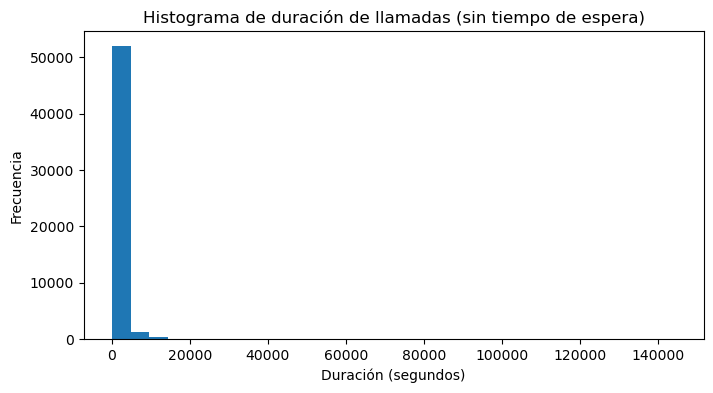

In [4]:
# Histograma de duración de las llamadas (sin tiempo de espera)
plt.figure(figsize=(8,4))
plt.hist(calls['call_duration'], bins=30)
plt.title('Histograma de duración de llamadas (sin tiempo de espera)')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.show()

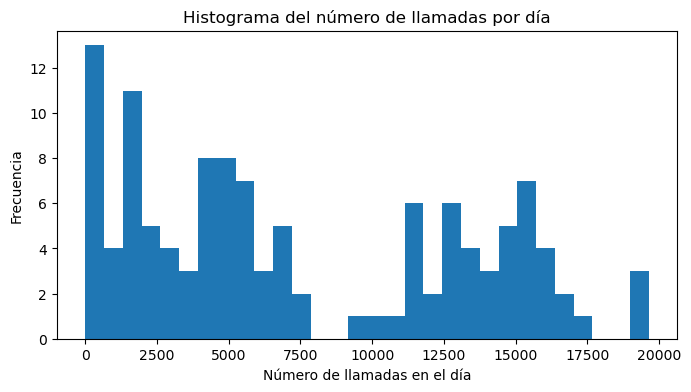

In [5]:
# Histograma de número de llamadas por día
calls_per_day = calls.groupby('date_only')['calls_count'].sum()

plt.figure(figsize=(8,4))
plt.hist(calls_per_day, bins=30)
plt.title('Histograma del número de llamadas por día')
plt.xlabel('Número de llamadas en el día')
plt.ylabel('Frecuencia')
plt.show()

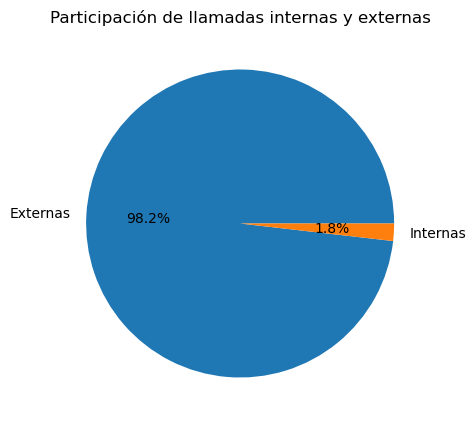

In [6]:
# Gráfico circular internas vs externas (todas las llamadas)
internal_counts = calls.groupby('internal')['calls_count'].sum()
labels = ['Externas', 'Internas']
sizes = [internal_counts[False], internal_counts[True]]

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Participación de llamadas internas y externas')
plt.show()

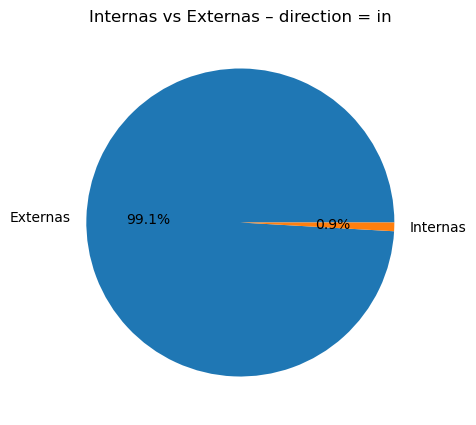

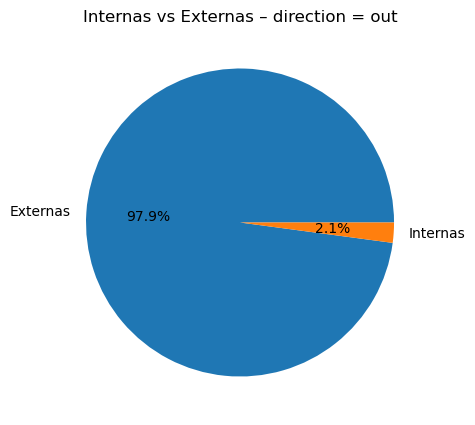

In [11]:
# Gráfico circular internas vs externas filtrando por dirección

def pie_internal_by_direction(direction_value):
    subset = calls[calls['direction'] == direction_value]
    internal_counts_dir = subset.groupby('internal')['calls_count'].sum()
    
    labels = ['Externas', 'Internas']
    sizes = [internal_counts_dir.get(False, 0), internal_counts_dir.get(True, 0)]
    
    plt.figure(figsize=(5,5))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%')
    plt.title(f'Internas vs Externas – direction = {direction_value}')
    plt.show()

pie_internal_by_direction('in')
pie_internal_by_direction('out')

In [12]:
# Ignorar filas sin operator_id 
ops = calls.dropna(subset=['operator_id']).copy()
ops['operator_id'] = ops['operator_id'].astype(int)

ops_metrics = ops.groupby('operator_id').agg(
    total_calls=('calls_count', 'sum'),
    missed_calls=('missed_calls', 'sum'),
    answered_calls=('answered_calls', 'sum'),
    incoming_calls=('incoming_calls', 'sum'),
    outgoing_calls=('outgoing_calls', 'sum'),
    mean_call_duration=('call_duration', 'mean'),
    mean_total_duration=('total_call_duration', 'mean'),
    mean_waiting_time=('waiting_time', 'mean')
)

ops_metrics['missed_rate'] = ops_metrics['missed_calls'] / ops_metrics['total_calls']

display(ops_metrics.head())

,total_calls,missed_calls,answered_calls,incoming_calls,outgoing_calls,mean_call_duration,mean_total_duration,mean_waiting_time,missed_rate
operator_id,,,,,,,,,
879896,1131,255,876,60,1071,650.476562,761.148438,110.671875,0.225464
879898,7974,2594,5380,118,7856,1111.067729,1561.155378,450.087649,0.325307
880020,54,30,24,8,46,104.090909,119.272727,15.181818,0.555556
880022,219,118,101,8,211,240.842105,298.407895,57.565789,0.538813
880026,2439,696,1743,25,2414,856.939394,978.111111,121.171717,0.285363


In [13]:
# Criterios basados en percentiles
missed_threshold = ops_metrics['missed_rate'].quantile(0.75)       # alto % de perdidas
wait_threshold = ops_metrics['mean_waiting_time'].quantile(0.75)   # alto tiempo de espera

# Para llamadas salientes
outgoing_nonzero = ops_metrics[ops_metrics['outgoing_calls'] > 0]['outgoing_calls']
if len(outgoing_nonzero) > 0:
    outgoing_threshold = outgoing_nonzero.quantile(0.25)           # pocos salientes
else:
    outgoing_threshold = 0

# Infeciencia
ops_metrics['high_missed'] = ops_metrics['missed_rate'] >= missed_threshold
ops_metrics['high_wait'] = ops_metrics['mean_waiting_time'] >= wait_threshold
ops_metrics['low_outgoing'] = ops_metrics['outgoing_calls'] > 0
ops_metrics.loc[ops_metrics['low_outgoing'], 'low_outgoing'] = \
    ops_metrics.loc[ops_metrics['low_outgoing'], 'outgoing_calls'] <= outgoing_threshold

ops_metrics['ineficaz'] = (
    ops_metrics['high_missed'] &
    ops_metrics['high_wait'] &
    (ops_metrics['low_outgoing'] | (ops_metrics['outgoing_calls'] == 0))
)

inefficient_ops = ops_metrics[ops_metrics['ineficaz']].copy()

print('Número de operadores ineficaces:', inefficient_ops.shape[0])
display(inefficient_ops.sort_values('missed_rate', ascending=False).head(10))

Número de operadores ineficaces: 0


,total_calls,missed_calls,answered_calls,incoming_calls,outgoing_calls,mean_call_duration,mean_total_duration,mean_waiting_time,missed_rate,high_missed,high_wait,low_outgoing,ineficaz
operator_id,,,,,,,,,,,,,


In [19]:
ops_metrics['ineficaz'].value_counts()
# Definir razonables
missed_threshold = ops_metrics['missed_rate'].quantile(0.90)
wait_threshold = ops_metrics['mean_waiting_time'].quantile(0.90)

# Nuevo criterio de ineficacia: top 10% peor en cualquiera de las dos métricas
ops_metrics['ineficaz'] = (
    (ops_metrics['missed_rate'] >= missed_threshold) |
    (ops_metrics['mean_waiting_time'] >= wait_threshold)
)

# Revisión
ops_metrics['ineficaz'].value_counts()

ineficaz
False    884
True     208
Name: count, dtype: int64

In [20]:
cols_to_show = [
    'total_calls', 'missed_calls', 'missed_rate',
    'incoming_calls', 'outgoing_calls',
    'mean_waiting_time', 'ineficaz'
]

summary_table = ops_metrics[cols_to_show].sort_values(
    ['ineficaz', 'missed_rate', 'mean_waiting_time'],
    ascending=[False, False, False]
)

display(summary_table.head(20))

,total_calls,missed_calls,missed_rate,incoming_calls,outgoing_calls,mean_waiting_time,ineficaz
operator_id,,,,,,,
909308,15,15,1.0,0,15,116.333333,True
932246,1,1,1.0,0,1,60.000000,True
962904,2,2,1.0,0,2,43.000000,True
937770,1,1,1.0,0,1,37.000000,True
936296,4,4,1.0,0,4,34.666667,True
945074,3,3,1.0,0,3,26.000000,True
899076,2,2,1.0,0,2,23.500000,True
891976,2,2,1.0,0,2,23.000000,True
937716,1,1,1.0,0,1,19.000000,True


In [21]:
#Grupos
wait_inef = ops_metrics.loc[ops_metrics['ineficaz'], 'mean_waiting_time']
wait_ok = ops_metrics.loc[~ops_metrics['ineficaz'], 'mean_waiting_time']

miss_inef = ops_metrics.loc[ops_metrics['ineficaz'], 'missed_rate']
miss_ok = ops_metrics.loc[~ops_metrics['ineficaz'], 'missed_rate']

# Prueba tiempo espera
stat_wait, p_wait = stats.mannwhitneyu(wait_inef, wait_ok, alternative='greater')

print("Hipótesis 1: Los operadores ineficaces tienen mayor tiempo de espera.")
print("Estadístico U:", stat_wait)
print("p-value:", p_wait)

# Prueba llamadas perdisds
stat_miss, p_miss = stats.mannwhitneyu(miss_inef, miss_ok, alternative='greater')

print("\nHipótesis 2: Los operadores ineficaces tienen mayor % de llamadas perdidas.")
print("Estadístico U:", stat_miss)
print("p-value:", p_miss)

Hipótesis 1: Los operadores ineficaces tienen mayor tiempo de espera.
Estadístico U: 127123.5
p-value: 4.050049458143822e-18

Hipótesis 2: Los operadores ineficaces tienen mayor % de llamadas perdidas.
Estadístico U: 171741.5
p-value: 1.2102276876555664e-85


## Resultados de las pruebas de hipótesis

Para evaluar si los operadores marcados como ineficaces se comportan de forma distinta al resto, se compararon las distribuciones usando la **prueba no paramétrica de Mann–Whitney U** (no asumimos normalidad).

### Hipótesis 1  
**H₀:** el tiempo de espera medio de los operadores ineficaces es igual que el de los operadores eficaces.  
**H₁:** el tiempo de espera medio de los operadores ineficaces es **mayor**.

- Estadístico U: `127123.5`  
- Valor p: `4.05e-18` (muy inferior a 0.05)

**Conclusión:** rechazamos la hipótesis nula. Hay evidencia estadística de que los operadores clasificados como ineficaces tienen **tiempos de espera significativamente mayores** que el resto.

### Hipótesis 2  
**H₀:** el porcentaje de llamadas perdidas de los operadores ineficaces es igual que el de los operadores eficaces.  
**H₁:** el porcentaje de llamadas perdidas de los operadores ineficaces es **mayor**.

- Estadístico U: `171741.5`  
- Valor p: `1.21e-85` (muy inferior a 0.05)

**Conclusión:** también rechazamos la hipótesis nula. Los operadores ineficaces presentan un **porcentaje de llamadas perdidas significativamente más alto** que los operadores eficaces.

En conjunto, ambas pruebas respaldan que los criterios utilizados para marcar a un operador como ineficaz capturan comportamientos claramente peores en las métricas clave de servicio.


## Fuentes y documentación consultada

**1. Documentación oficial de pandas**  
https://pandas.pydata.org/docs/  

Me ayudó a recordar las funciones necesarias para **leer archivos CSV**, convertir columnas de fecha a `datetime`, agrupar datos por operador y calcular métricas agregadas.

**2. Documentación oficial de Matplotlib**  
https://matplotlib.org/stable/  

La utilicé para revisar ejemplos de cómo trazar **histogramas** y **gráficos circulares**, que luego apliqué en los dashboards de llamadas y tiempos de espera.

**3. Documentación de SciPy – `scipy.stats.mannwhitneyu`**  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html  

Sirvió para entender cómo aplicar la **prueba de Mann–Whitney U**, qué parámetros usar y cómo interpretar el estadístico y el valor p al comparar dos grupos de operadores.

**4. Stack Overflow**  
https://stackoverflow.com/  

Lo usé como referencia general para resolver dudas puntuales sobre **advertencias de pandas**, detalles de agrupamientos y manejo de valores `NaN`.

**5. Artículo de Medium sobre análisis exploratorio de datos (EDA)**  
https://medium.com/  

Me dio una guía práctica para estructurar la sección de **EDA**, decidir qué métricas revisar primero y cómo presentar los gráficos para que sean fáciles de interpretar.

**6. Documentación de Jupyter Notebook**  
https://jupyter-notebook.readthedocs.io/  

Me ayudó a configurar celdas de **Markdown**, crear títulos y listas y dar un formato más profesional al Notebook del proyecto final.
